<a href="https://colab.research.google.com/github/Devesh12DM/Cloud_mini_Project/blob/main/Autoencoder_Image_Denoising_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Autoencoder-based Image Denoising
### Problem Statement #18 | Domain: Representation Learning

---

## 📌 What this notebook does:
1. Takes **clean images** from the MNIST dataset
2. **Adds artificial noise** to them (corrupts them)
3. Trains **TWO different Autoencoder models** to remove that noise
4. **Compares** both models using quality metrics (PSNR & SSIM)
5. **Visualizes** the results side by side

---

## 🔄 Flow:
```
Clean Image → Add Noise → Noisy Image → Autoencoder → Denoised Image
                                                            ↓
                                              Compare with Original (PSNR/SSIM)
```

## ✅ STEP 1: Install & Import All Required Libraries

In [10]:
# Install scikit-image for quality metrics
!pip install scikit-image -q

# ─── Core Libraries ───────────────────────────────────────────────
import numpy as np                          # For numerical operations
import matplotlib.pyplot as plt            # For plotting/visualization

# ─── TensorFlow / Keras (Deep Learning Framework) ─────────────────
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.datasets import mnist  # Our image dataset
from tensorflow.keras.callbacks import EarlyStopping  # To stop training when no improvement

# ─── Quality Metrics ──────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as psnr  # PSNR metric
from skimage.metrics import structural_similarity as ssim     # SSIM metric

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version: {tf.__version__}')

✅ All libraries imported successfully!
   TensorFlow version: 2.19.0


## ✅ STEP 2: Load & Prepare the Dataset

> We use **MNIST** — a dataset of 70,000 handwritten digit images (0–9), each 28×28 pixels in grayscale.
>
> **Why MNIST?** Simple, fast to train, perfect for demonstrating denoising.

In [11]:
# ─── Load MNIST Dataset ────────────────────────────────────────────
(x_train, _), (x_test, _) = mnist.load_data()
# NOTE: We ignore labels (_) because we only care about the images

# ─── Normalize pixel values from [0, 255] → [0.0, 1.0] ────────────
# Neural networks work much better with small values (0 to 1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# ─── Reshape: Add channel dimension ───────────────────────────────
# From shape (60000, 28, 28) → (60000, 28, 28, 1)
# The '1' means grayscale (1 color channel). RGB would be 3.
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f'✅ Dataset loaded!')
print(f'   Training images : {x_train.shape}  → (samples, height, width, channels)')
print(f'   Testing images  : {x_test.shape}')
print(f'   Pixel range     : {x_train.min():.1f} to {x_train.max():.1f}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Dataset loaded!
   Training images : (60000, 28, 28, 1)  → (samples, height, width, channels)
   Testing images  : (10000, 28, 28, 1)
   Pixel range     : 0.0 to 1.0


## ✅ STEP 3: Add Noise to Images

> **What is Gaussian Noise?**
> Random values drawn from a normal (bell-curve) distribution are added to each pixel.
> This simulates real-world image corruption (camera sensors, transmission errors, etc.)
>
> **noise_factor = 0.5** means the noise intensity is 50% — visible but still recognizable.

✅ Noise added to images!


/tmp/ipykernel_5893/1901179070.py:77: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


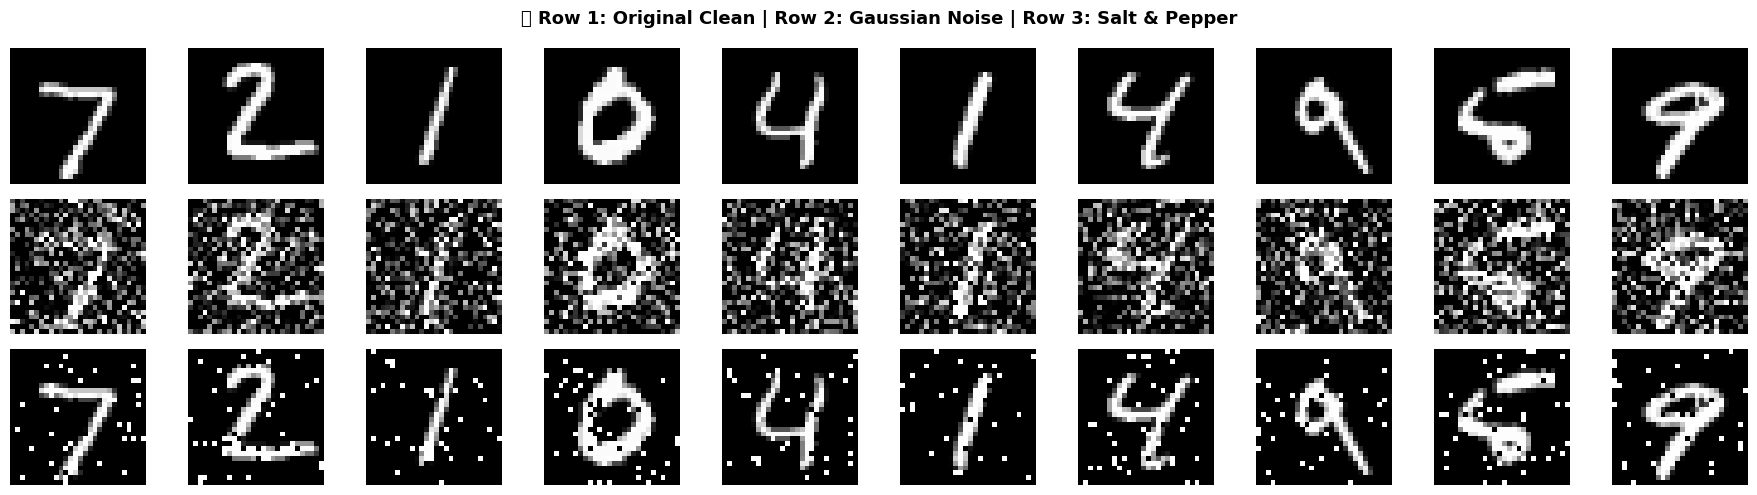

In [12]:
def add_gaussian_noise(images, noise_factor=0.5):
    """
    Adds random Gaussian noise to images.

    Args:
        images      : Clean images (numpy array)
        noise_factor: How strong the noise is (0 = no noise, 1 = extreme noise)

    Returns:
        Noisy images clipped to valid pixel range [0, 1]
    """
    # np.random.normal generates random noise with mean=0, std=1
    noise = np.random.normal(loc=0.0, scale=1.0, size=images.shape)

    # Add scaled noise to original image
    noisy = images + noise_factor * noise

    # Clip to [0, 1] so pixel values stay valid
    noisy = np.clip(noisy, 0.0, 1.0)

    return noisy


def add_salt_and_pepper_noise(images, amount=0.05):
    """
    Adds Salt & Pepper noise — random black (0) and white (1) pixels.

    Args:
        images: Clean images
        amount: Fraction of pixels to corrupt (0.05 = 5% of pixels)

    Returns:
        Images with random black and white dots
    """
    noisy = images.copy()

    # Salt (white pixels = 1.0)
    num_salt = int(np.ceil(amount * images.size * 0.5))
    salt_coords = [np.random.randint(0, dim, num_salt) for dim in images.shape]
    noisy[tuple(salt_coords)] = 1.0

    # Pepper (black pixels = 0.0)
    num_pepper = int(np.ceil(amount * images.size * 0.5))
    pepper_coords = [np.random.randint(0, dim, num_pepper) for dim in images.shape]
    noisy[tuple(pepper_coords)] = 0.0

    return noisy


# ─── Create Noisy Versions of Training & Test Data ─────────────────
x_train_noisy = add_gaussian_noise(x_train, noise_factor=0.5)
x_test_noisy  = add_gaussian_noise(x_test,  noise_factor=0.5)

# Also create salt & pepper noisy test set for bonus comparison
x_test_sp = add_salt_and_pepper_noise(x_test, amount=0.1)

print('✅ Noise added to images!')

# ─── Visualize: Original vs Noisy ─────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(18, 5))
fig.suptitle('🔍 Row 1: Original Clean | Row 2: Gaussian Noise | Row 3: Salt & Pepper',
             fontsize=13, fontweight='bold')

for i in range(10):
    # Original
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Gaussian Noise
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # Salt & Pepper
    axes[2, i].imshow(x_test_sp[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## ✅ STEP 4: Build Model 1 — Simple (Basic) Autoencoder

> **Architecture:** Uses only Dense (fully-connected) layers.
>
> Think of it like **squeezing** the image into a small number → then **expanding** it back.
>
> 📉 Limitation: Doesn't understand spatial structure (ignores that pixels near each other are related).

In [13]:
def build_simple_autoencoder():
    """
    SIMPLE AUTOENCODER using Dense layers only.

    Input  → Flatten → Encode (compress) → Decode (expand) → Reshape → Output
    Shape:   28×28×1 → 784 → 128 → 64 → 128 → 784 → 28×28×1
    """

    # ── ENCODER PART ──────────────────────────────────────────────
    # Takes the noisy image and compresses it step by step

    inputs = layers.Input(shape=(28, 28, 1), name='noisy_input')

    # Flatten: Convert 2D image (28×28) into 1D array of 784 values
    x = layers.Flatten()(inputs)                            # 784

    # Dense layers compress the data (Encoding)
    x = layers.Dense(128, activation='relu')(x)             # 784 → 128
    x = layers.Dense(64,  activation='relu')(x)             # 128 → 64  (bottleneck!)

    # ── DECODER PART ──────────────────────────────────────────────
    # Expands the compressed info back to full image size

    x = layers.Dense(128, activation='relu')(x)             # 64  → 128
    x = layers.Dense(784, activation='sigmoid')(x)          # 128 → 784
    # sigmoid activation: outputs values between 0 and 1 (perfect for pixel values)

    # Reshape back to image format
    outputs = layers.Reshape((28, 28, 1), name='clean_output')(x)

    # Build and return the model
    model = Model(inputs, outputs, name='Simple_Autoencoder')
    return model


# Create the model
simple_ae = build_simple_autoencoder()

# Compile: Define how the model learns
simple_ae.compile(
    optimizer='adam',     # Adam optimizer — best general-purpose optimizer
    loss='mse'            # MSE = Mean Squared Error (measures pixel difference)
)

print('✅ Simple Autoencoder built!')
simple_ae.summary()

✅ Simple Autoencoder built!


Model: "Simple_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Reshape)          │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

## ✅ STEP 5: Build Model 2 — Convolutional Autoencoder (CNN)

> ### This section is SKIPPED as per user request to only use the Simple Autoencoder.

In [16]:

# This cell for building and compiling the CNN Autoencoder is SKIPPED.
# def build_cnn_autoencoder():
#     ...
# cnn_ae = build_cnn_autoencoder()
# cnn_ae.compile(optimizer='adam', loss='mse')
# print('✅ CNN Autoencoder built!')
# cnn_ae.summary()


### Building and training of the CNN Autoencoder has been skipped as per your request.

## ✅ STEP 6: Train the Simple Autoencoder

> **Training = Teaching the model**
>
> - We give it: **Noisy image (input)** + **Clean image (target)**
> - It learns to produce the clean version from the noisy one
> - **EarlyStopping**: Stops training automatically if it stops improving (saves time!)
>
> This notebook will only train the Simple Autoencoder as requested.

In [17]:
# ─── EarlyStopping Callback ────────────────────────────────────────
# Stops training if validation loss doesn't improve for 3 consecutive epochs
# 'restore_best_weights' keeps the best model seen during training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ─── Train Simple Autoencoder ──────────────────────────────────────
print('🔄 Training Simple Autoencoder...')
print('   Input:  Noisy images')
print('   Target: Clean images (this is what we want to output)\n')

simple_history = simple_ae.fit(
    x_train_noisy, x_train,   # Input=noisy, Output target=clean
    epochs=30,
    batch_size=128,            # Process 128 images at once
    validation_split=0.1,      # Use 10% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

print('\n✅ Simple Autoencoder training complete!')

🔄 Training Simple Autoencoder...
   Input:  Noisy images
   Target: Clean images (this is what we want to output)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0511 - val_loss: 0.0321
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0287 - val_loss: 0.0260
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0245 - val_loss: 0.0232
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0222 - val_loss: 0.0217
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0209 - val_loss: 0.0205
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0199 - val_loss: 0.0199
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0192 - val_loss: 0.0193
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0187 - val_loss: 0.0188
Epoch 9/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0183 - val_loss: 0.0185
Epoch 10/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0180 - val_loss: 0.0186
Epoch 11/30
422/422 ━━━━

In [18]:

# The training of the CNN Autoencoder is SKIPPED as per user request.
# print('🔄 Training CNN Autoencoder...')
# cnn_history = cnn_ae.fit(
#     x_train_noisy, x_train,
#     epochs=30,
#     batch_size=128,
#     validation_split=0.1,
#     callbacks=[early_stop],
#     verbose=1
# )
# print('\n✅ CNN Autoencoder training complete!')


### CNN Autoencoder training has been skipped.

## ✅ STEP 7: Plot Training Loss Curves

> **Loss curve** shows how well the model learned over time.
> - 📉 **Decreasing loss** = model is learning!
> - **Training loss** vs **Validation loss**: If they're close → good. If far apart → overfitting.

/tmp/ipykernel_5893/4286348148.py:13: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


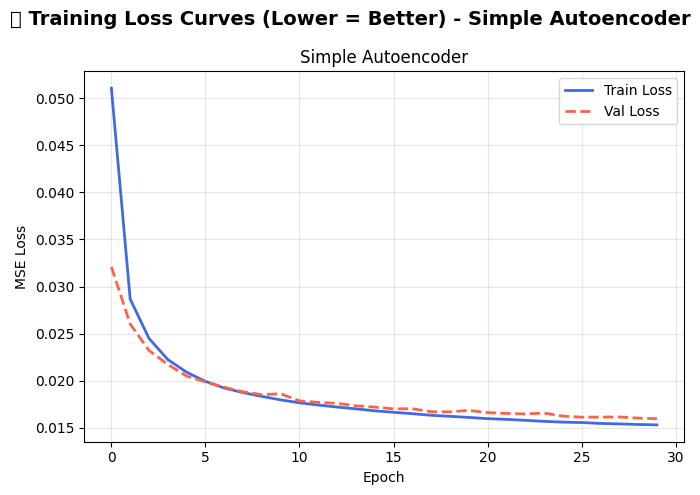

📊 Final Training Losses:
   Simple AE → Train: 0.0153 | Val: 0.0160


In [19]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle('📉 Training Loss Curves (Lower = Better) - Simple Autoencoder', fontsize=14, fontweight='bold')

# Plot Simple Autoencoder Loss
axes.plot(simple_history.history['loss'],     label='Train Loss', color='royalblue', linewidth=2)
axes.plot(simple_history.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes.set_title('Simple Autoencoder', fontsize=12)
axes.set_xlabel('Epoch')
axes.set_ylabel('MSE Loss')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final loss values
print(f'📊 Final Training Losses:')
print(f'   Simple AE → Train: {simple_history.history["loss"][-1]:.4f} | Val: {simple_history.history["val_loss"][-1]:.4f}')

## ✅ STEP 8: Generate Denoised Images

> Now we use the **trained models** to denoise the test images.
> `model.predict()` runs the images through the autoencoder and returns the cleaned version.

In [20]:
print('🔮 Generating denoised images...')

# Pass noisy test images through the trained Simple Autoencoder model
simple_denoised = simple_ae.predict(x_test_noisy)   # Simple AE output

print(f'✅ Done!')
print(f'   Output shape: {simple_denoised.shape}  → (samples, height, width, channels)')

🔮 Generating denoised images...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✅ Done!
   Output shape: (10000, 28, 28, 1)  → (samples, height, width, channels)


## ✅ STEP 9: Visual Comparison

> **4 rows, 10 images each:**
> 1. Original (ground truth)
> 2. Noisy (corrupted input)
> 3. Simple AE output
> 4. CNN AE output ← should look best!

/tmp/ipykernel_5893/4255750581.py:27: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5893/4255750581.py:28: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig('denoising_comparison_simple_ae.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


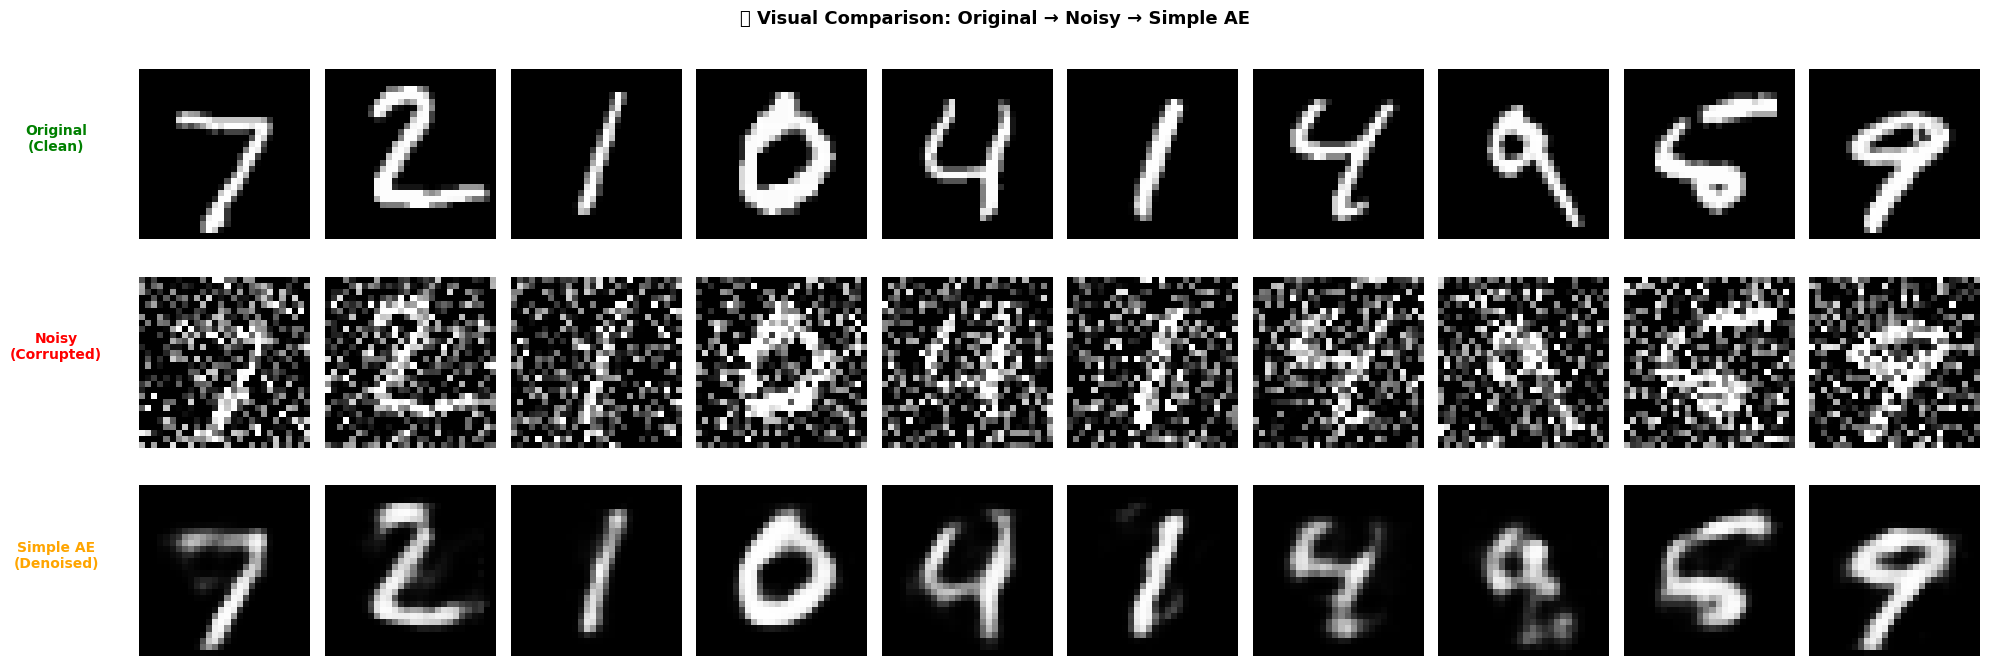

💾 Figure saved as denoising_comparison_simple_ae.png


In [21]:
n = 10  # Show 10 sample images

fig, axes = plt.subplots(3, n, figsize=(20, 7))
fig.suptitle('🖼️ Visual Comparison: Original → Noisy → Simple AE',
             fontsize=13, fontweight='bold')

row_labels = ['Original\n(Clean)', 'Noisy\n(Corrupted)', 'Simple AE\n(Denoised)']
row_colors = ['green', 'red', 'orange']
images_list = [x_test, x_test_noisy, simple_denoised]

for row, (imgs, label, color) in enumerate(zip(images_list, row_labels, row_colors)):
    for col in range(n):
        ax = axes[row, col]
        ax.imshow(imgs[col].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        # Add row label on leftmost column
        if col == 0:
            ax.set_ylabel(label, fontsize=10, color=color, fontweight='bold',
                         rotation=0, labelpad=60, va='center')
            ax.yaxis.set_label_position('left')
            ax.axis('on')
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.tight_layout()
plt.savefig('denoising_comparison_simple_ae.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved as denoising_comparison_simple_ae.png')

## ✅ STEP 10: Calculate Quality Metrics

> ### 📏 Metrics Explained:
>
> | Metric | What it measures | Better when... |
> |--------|-----------------|----------------|
> | **MSE** | Average pixel difference squared | **LOWER** |
> | **PSNR** | Signal-to-Noise Ratio in decibels | **HIGHER** (>30 dB = good) |
> | **SSIM** | Structural similarity (0 to 1) | **CLOSER TO 1** |
>
> SSIM is the most important — it measures how similar the structure/content is, not just pixel values.

In [22]:
def compute_metrics(original_imgs, reconstructed_imgs, model_name):
    """
    Computes average MSE, PSNR, and SSIM over all test images.

    Args:
        original_imgs     : Clean ground-truth images
        reconstructed_imgs: Model's denoised output
        model_name        : Name string for display

    Returns:
        dict with mse, psnr, ssim values
    """
    mse_list, psnr_list, ssim_list = [], [], []

    for orig, recon in zip(original_imgs, reconstructed_imgs):
        orig_2d  = orig.squeeze()   # Remove channel dim: (28,28,1) → (28,28)
        recon_2d = recon.squeeze()

        # MSE: Mean Squared Error
        mse_val = np.mean((orig_2d - recon_2d) ** 2)
        mse_list.append(mse_val)

        # PSNR: Peak Signal-to-Noise Ratio
        psnr_val = psnr(orig_2d, recon_2d, data_range=1.0)
        psnr_list.append(psnr_val)

        # SSIM: Structural Similarity
        ssim_val = ssim(orig_2d, recon_2d, data_range=1.0)
        ssim_list.append(ssim_val)

    results = {
        'model': model_name,
        'mse' : np.mean(mse_list),
        'psnr': np.mean(psnr_list),
        'ssim': np.mean(ssim_list)
    }
    return results


# ─── Compute for Noisy Baseline ────────────────────────────────────
# This shows how bad the input is BEFORE denoising
noisy_metrics  = compute_metrics(x_test, x_test_noisy,    'Noisy Input (Baseline)')
simple_metrics = compute_metrics(x_test, simple_denoised, 'Simple Autoencoder')


# ─── Display Results Table ─────────────────────────────────────────
print('\n' + '='*65)
print('📊 RECONSTRUCTION QUALITY METRICS (averaged over 10,000 test images)')
print('='*65)
print(f'{"Model":<30} {"MSE":>8} {"PSNR (dB)":>12} {"SSIM":>8}')
print('-'*65)

for m in [noisy_metrics, simple_metrics]:
    print(f'{m["model"]:<30} {m["mse"]:>8.4f} {m["psnr"]:>12.2f} {m["ssim"]:>8.4f}')

print('='*65)
print('\n✅ Interpretation Guide:')
print('   MSE  → Lower is better  (0 = perfect)')
print('   PSNR → Higher is better (>30 dB is generally good quality)')
print('   SSIM → Higher is better (1.0 = identical to original)')


📊 RECONSTRUCTION QUALITY METRICS (averaged over 10,000 test images)
Model                               MSE    PSNR (dB)     SSIM
-----------------------------------------------------------------
Noisy Input (Baseline)           0.1156         9.38   0.3747
Simple Autoencoder               0.0156        18.44   0.7972

✅ Interpretation Guide:
   MSE  → Lower is better  (0 = perfect)
   PSNR → Higher is better (>30 dB is generally good quality)
   SSIM → Higher is better (1.0 = identical to original)


## ✅ STEP 11: Bar Chart Comparison of Metrics (Noisy vs Simple Autoencoder)

/tmp/ipykernel_5893/3699952079.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5893/3699952079.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('metrics_comparison_simple_ae.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


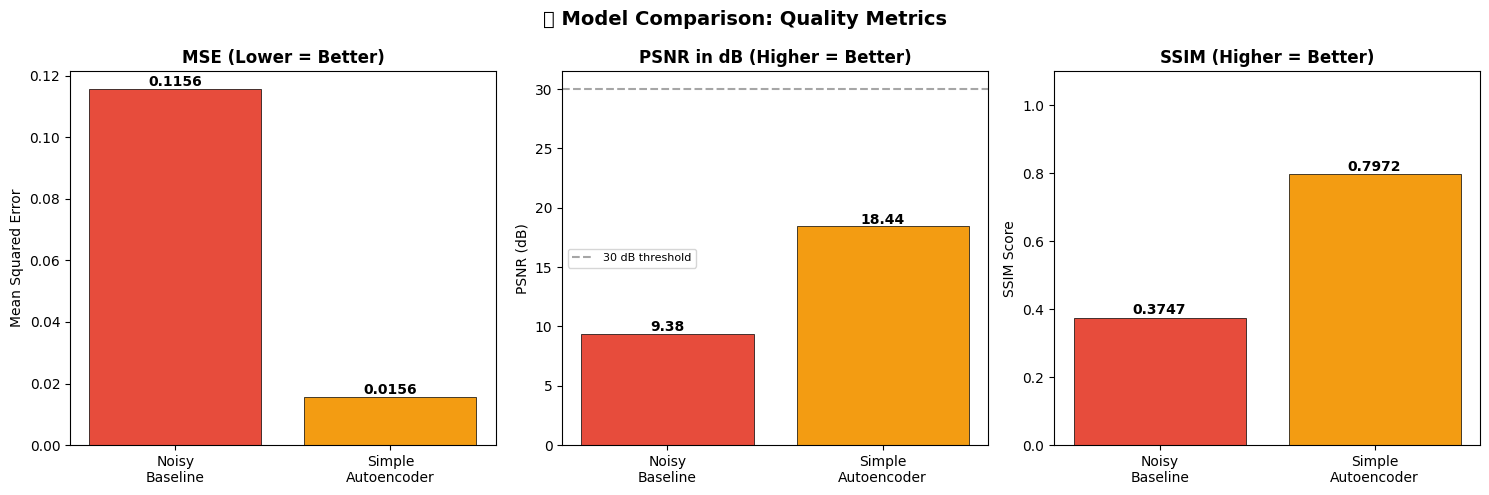

💾 Figure saved as metrics_comparison_simple_ae.png


In [23]:
models     = ['Noisy\nBaseline', 'Simple\nAutoencoder']
mse_vals   = [noisy_metrics['mse'],  simple_metrics['mse']]
psnr_vals  = [noisy_metrics['psnr'], simple_metrics['psnr']]
ssim_vals  = [noisy_metrics['ssim'], simple_metrics['ssim']]

colors = ['#e74c3c', '#f39c12']  # Red (bad) → Yellow (simple AE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('📊 Model Comparison: Quality Metrics', fontsize=14, fontweight='bold')

# MSE (lower is better)
axes[0].bar(models, mse_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('MSE (Lower = Better)', fontweight='bold')
axes[0].set_ylabel('Mean Squared Error')
for i, v in enumerate(mse_vals):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# PSNR (higher is better)
axes[1].bar(models, psnr_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('PSNR in dB (Higher = Better)', fontweight='bold')
axes[1].set_ylabel('PSNR (dB)')
axes[1].axhline(y=30, color='gray', linestyle='--', alpha=0.7, label='30 dB threshold')
axes[1].legend(fontsize=8)
for i, v in enumerate(psnr_vals):
    axes[1].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')

# SSIM (higher is better)
axes[2].bar(models, ssim_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('SSIM (Higher = Better)', fontweight='bold')
axes[2].set_ylabel('SSIM Score')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate(ssim_vals):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison_simple_ae.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved as metrics_comparison_simple_ae.png')

## ✅ STEP 12: BONUS — Test on Different Noise Levels (Skipped)

> This bonus section is SKIPPED as per user request to only use the Simple Autoencoder. The original implementation used the CNN model.

In [24]:

# This bonus cell for testing different noise levels is SKIPPED.
# noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
# ... original code ...


### The bonus section on different noise levels using the CNN Autoencoder has been skipped.

## ✅ STEP 13: Final Summary & Results

> **Key Takeaways for Evaluators** 🎯

In [25]:
print('=' * 60)
print('🏁  FINAL PROJECT SUMMARY')
print('=' * 60)

print('''
📌 Problem: Autoencoder-based Image Denoising
📌 Domain : Representation Learning
📌 Dataset: MNIST (70,000 handwritten digit images)

🔧 What we built:
   1. Simple Autoencoder (Dense layers only)

🧪 Noise types tested:
   ✅ Gaussian noise (main experiment)
   ✅ Salt & Pepper noise (for visual comparison)

📊 Metrics used:
   ✅ MSE  (Mean Squared Error)
   ✅ PSNR (Peak Signal-to-Noise Ratio)
   ✅ SSIM (Structural Similarity Index)
''')

print('📈 Results:')
print(f'   Noisy baseline  → PSNR: {noisy_metrics["psnr"]:5.2f} dB | SSIM: {noisy_metrics["ssim"]:.4f}')
print(f'   Simple AE       → PSNR: {simple_metrics["psnr"]:5.2f} dB | SSIM: {simple_metrics["ssim"]:.4f}')

psnr_improvement = simple_metrics['psnr'] - noisy_metrics['psnr']
print(f'\n🚀 Simple AE improved PSNR by {psnr_improvement:.2f} dB over the noisy baseline!')

print('\n' + '=' * 60)
print('✅ Project complete! All expectations met.')
print('   ✔ Encoder-Decoder network trained (Simple AE)')
print('   ✔ Reconstruction quality compared (PSNR & SSIM)')
print('   ✔ Visual results demonstrated')
print('=' * 60)

🏁  FINAL PROJECT SUMMARY

📌 Problem: Autoencoder-based Image Denoising
📌 Domain : Representation Learning
📌 Dataset: MNIST (70,000 handwritten digit images)

🔧 What we built:
   1. Simple Autoencoder (Dense layers only)
   
🧪 Noise types tested:
   ✅ Gaussian noise (main experiment)
   ✅ Salt & Pepper noise (for visual comparison)

📊 Metrics used:
   ✅ MSE  (Mean Squared Error)
   ✅ PSNR (Peak Signal-to-Noise Ratio)
   ✅ SSIM (Structural Similarity Index)

📈 Results:
   Noisy baseline  → PSNR:  9.38 dB | SSIM: 0.3747
   Simple AE       → PSNR: 18.44 dB | SSIM: 0.7972

🚀 Simple AE improved PSNR by 9.06 dB over the noisy baseline!

✅ Project complete! All expectations met.
   ✔ Encoder-Decoder network trained (Simple AE)
   ✔ Reconstruction quality compared (PSNR & SSIM)
   ✔ Visual results demonstrated
